# Tutorial – Session 7

## Intervalestimation og konfidensintervaller

Denne tutorial følger **Ross, kapitel 7**, afsnit **7.1**, **7.3**, **7.4** og **7.5** (jf. sessionbeskrivelsen). For hvert emne gives først de centrale formler og fortolkninger, derefter **Python**-eksempler med `numpy`, `scipy.stats` og `matplotlib`.

**Notebook-version:** [Tutorial_7_notebook.ipynb](Tutorial_7_notebook.ipynb)

**Ekstra plot-notebook:** [plot_normal_distribution.ipynb](plot_normal_distribution.ipynb)

---

## 1. Introduktion og opsætning

Vi arbejder med konfidensintervaller for middelværdi, varians, forskel mellem middelværdier og andele, samt **prædiktionsintervaller** for en ny observation. Biblioteker:

- `numpy` – tal og stikprøvestatistikker
- `scipy.stats` – `norm`, `t`, `chi2` (og sandsynligheder)
- `matplotlib.pyplot` – plots (fx normalfordelingsplot)



In [45]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, t, chi2, probplot

np.random.seed(42)
plt.rcParams["figure.figsize"] = (10, 6)
plt.style.use("ggplot")



---

## 2. Normal probability plot (QQ-plot) og normalitetscheck

Flere af intervallerne i denne session (særligt klassiske $t$-intervaller, prædiktionsintervaller i normalmodellen og $\chi^2$-intervaller for varians) bygger på antagelser om normalfordeling. Derfor er det god praksis at starte med et **normal probability plot** (QQ-plot).

### Hvorfor tjekke normalitet?

- For små og mellemstore stikprøver kan ikke-normalitet påvirke intervalkvaliteten markant.
- Et QQ-plot giver et hurtigt visuelt check af, om data følger en omtrent lineær normalstruktur.
- Tydelige afvigelser i halerne eller enkeltstående outliers er et signal om, at man bør være forsigtig med standardformlerne.

### Hvordan fortolker man QQ-plot?

- Punkter tæt på en ret linje: data er omtrent normalfordelte.
- Systematisk krumning (S-form): skævhed eller tunge/lette haler.
- Få punkter langt fra linjen: mulige outliers.

Du kan også se en separat og mere visuelt orienteret notebook her: [plot_normal_distribution.ipynb](plot_normal_distribution.ipynb).



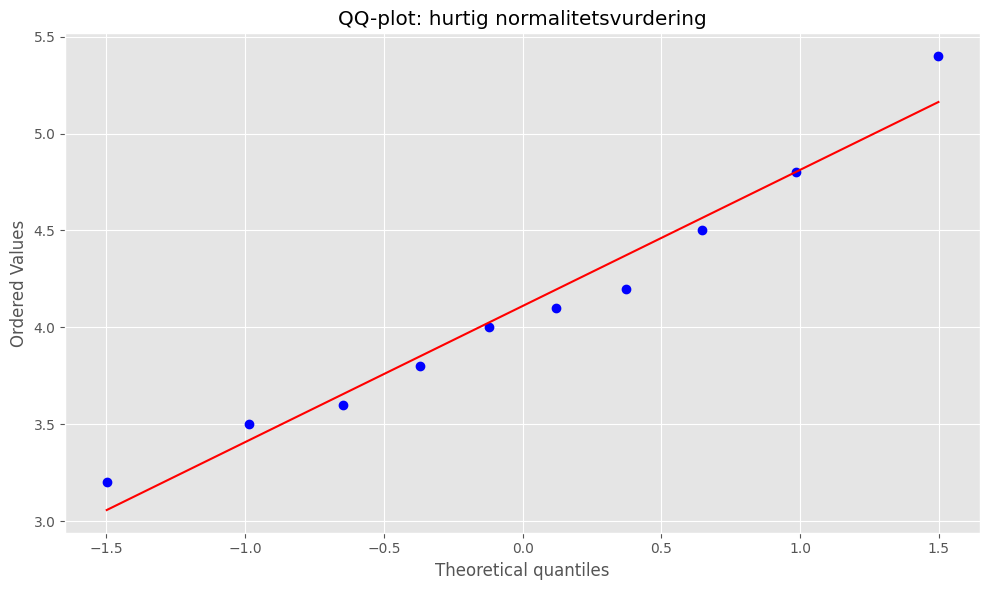

In [46]:
# Eksempel: normal probability plot (QQ-plot)
sample_data = np.array([3.2, 3.5, 3.6, 3.8, 4.0, 4.1, 4.2, 4.5, 4.8, 5.4])

fig, ax = plt.subplots()
probplot(sample_data, dist="norm", plot=ax)
ax.set_title("QQ-plot: hurtig normalitetsvurdering")
plt.tight_layout()
plt.show()



---

## 3. Indledning til konfidensintervaller for middelværdi

Et **$100(1-\alpha)\,\%$ konfidensinterval** for en parameter er konstrueret sådan, at **hvis vi gentager forsøget** (ny stikprøve, samme procedure), så vil cirka $100(1-\alpha)\,\%$ af de således beregnede intervaller indeholde den **sande** parameter.

**Vigtigt:** Det er **ikke** korrekt at sige, at “sandsynligheden for at $\mu$ ligger i dette interval er $95\,\%$” *efter* data er observeret — intervallet er fast, og $\mu$ er ikke en tilfældig variabel i den frekventistiske fortolkning.

I de næste to underafsnit gennemgår vi CI for middelværdi i normalmodellen for hhv. kendt og ukendt populationsstandardafvigelse.

---

### 3.1 Konfidensinterval for $\mu$ når $\sigma$ er kendt (normalpopulation)

Antag $X_1,\ldots,X_n$ uafhængige $N(\mu,\sigma^2)$ med **kendt** $\sigma$. Så er
$$Z = \frac{\bar{X}-\mu}{\sigma/\sqrt{n}} \sim N(0,1).$$

**Tosidet** $100(1-\alpha)\,\%$-CI:
$$\bar{x} \pm z_{\alpha/2}\,\frac{\sigma}{\sqrt{n}}.$$

**Ensidet nedre** grænse ($\mu$ er mindst … med konfidens $1-\alpha$):
$$\bar{x} - z_{\alpha}\,\frac{\sigma}{\sqrt{n}} \leq \mu.$$

**Ensidet øvre** analogt med $+$ og $z_\alpha$.



In [47]:
# 1-til-1 implementering af formlen (uden helper-funktion)
xbar = 100.0
sigma = 15.0
n = 36
confidence = 0.95

alpha = 1 - confidence
se = sigma / np.sqrt(n)
z_crit = norm.ppf(1 - alpha / 2)

lo = xbar - z_crit * se
hi = xbar + z_crit * se
print(f"95% tosidet z-CI: [{lo:.4f}, {hi:.4f}]")

# Ensidet nedre grænse:
z_alpha = norm.ppf(1 - alpha)
lower_bound = xbar - z_alpha * se
print(f"95% ensidet nedre grænse: mu >= {lower_bound:.4f}")

# (valgfrit) helper-funktion til genbrug:
def ci_mean_sigma_known(xbar, sigma, n, confidence=0.95, side="two"):
    alpha = 1 - confidence
    se = sigma / np.sqrt(n)
    if side == "two":
        z = norm.ppf(1 - alpha / 2)
        return xbar - z * se, xbar + z * se
    if side == "lower":
        z = norm.ppf(1 - alpha)
        return xbar - z * se, np.inf
    if side == "upper":
        z = norm.ppf(1 - alpha)
        return -np.inf, xbar + z * se
    raise ValueError("ukendt side")


95% tosidet z-CI: [95.1001, 104.8999]
95% ensidet nedre grænse: mu >= 95.8879



### 3.2 Konfidensinterval for $\mu$ når $\sigma$ er ukendt ($t$-fordeling)

Erstat $\sigma$ med $S$ (stikprøvestandardafvigelse). Pivot:
$$T = \frac{\bar{X}-\mu}{S/\sqrt{n}} \sim t_{n-1}.$$

**Tosidet** CI:
$$\bar{x} \pm t_{\alpha/2,\,n-1}\,\frac{s}{\sqrt{n}}.$$



In [48]:
# 1-til-1 implementering af t-intervallet (uden helper-funktion)
x = np.array([9.8, 10.2, 10.1, 9.9, 10.5, 9.7, 10.0, 10.3, 9.8, 10.1])
confidence = 0.95

n = len(x)
xbar = np.mean(x)
s = np.std(x, ddof=1)
df = n - 1
alpha = 1 - confidence
se = s / np.sqrt(n)
t_crit = t.ppf(1 - alpha / 2, df)

lo = xbar - t_crit * se
hi = xbar + t_crit * se
print(f"95% tosidet t-CI: [{lo:.4f}, {hi:.4f}]")

# Ensidet nedre grænse:
t_alpha = t.ppf(1 - alpha, df)
lower_bound = xbar - t_alpha * se
print(f"95% ensidet nedre grænse: mu >= {lower_bound:.4f}")

# (valgfrit) helper-funktion til genbrug:
def ci_mean_sigma_unknown(x, confidence=0.95, side="two"):
    x = np.asarray(x, dtype=float)
    n = len(x)
    xbar = np.mean(x)
    s = np.std(x, ddof=1)
    df = n - 1
    alpha = 1 - confidence
    se = s / np.sqrt(n)
    if side == "two":
        tcrit = t.ppf(1 - alpha / 2, df)
        return xbar - tcrit * se, xbar + tcrit * se
    if side == "lower":
        tcrit = t.ppf(1 - alpha, df)
        return xbar - tcrit * se, np.inf
    if side == "upper":
        tcrit = t.ppf(1 - alpha, df)
        return -np.inf, xbar + tcrit * se
    raise ValueError("side skal være 'two', 'lower' eller 'upper'")


95% tosidet t-CI: [9.8609, 10.2191]
95% ensidet nedre grænse: mu >= 9.8949



---

## 4. Prædiktionsinterval for en ny observation (Ross 7.3.2)

Målet er **én ny** observation $X_{n+1}$, ikke $\mu$.

- **$\sigma$ kendt:** med pivot der udnytter uafhængighed mellem $\bar{X}$ og den nye observation fås typisk
  $$\bar{x} \pm z_{\alpha/2}\,\sigma\sqrt{1+\frac{1}{n}}.$$
- **$\sigma$ ukendt (erstattes med $s$):**
  $$\bar{x} \pm t_{\alpha/2,\,n-1}\,s\sqrt{1+\frac{1}{n}}.$$

Bemærk faktoren $\sqrt{1+1/n}$ i stedet for kun $\sigma/\sqrt{n}$ — der er både usikkerhed på $\mu$ og spredning på den nye måling.



In [49]:
def prediction_interval(x, confidence=0.95, sigma=None, side="two"):
    x = np.asarray(x, dtype=float)
    n = len(x)
    xbar = np.mean(x)
    s = np.std(x, ddof=1)
    df = n - 1
    alpha = 1 - confidence
    if sigma is not None:
        if side == "two":
            z = norm.ppf(1 - alpha / 2)
            half = z * sigma * np.sqrt(1 + 1 / n)
        else:
            raise NotImplementedError("brug tosidet eller udvid med z_alpha")
        return xbar - half, xbar + half
    if side == "two":
        tcrit = t.ppf(1 - alpha / 2, df)
        half = tcrit * s * np.sqrt(1 + 1 / n)
        return xbar - half, xbar + half
    raise NotImplementedError



---

## 5. Konfidensintervaller for $\sigma^2$ og $\sigma$ ($\chi^2$, normalpopulation)

For normalfordelte data gælder
$$\frac{(n-1)S^2}{\sigma^2} \sim \chi^2_{n-1}.$$

**Tosidet** $100(1-\alpha)\,\%$ CI for $\sigma^2$:
$$\left(\frac{(n-1)s^2}{\chi^2_{\alpha/2,\,n-1}},\;\frac{(n-1)s^2}{\chi^2_{1-\alpha/2,\,n-1}}\right).$$

**Ensidet øvre** grænse for $\sigma^2$ (ønsker “$\sigma^2$ er højst …”):
$$\sigma^2 \leq \frac{(n-1)s^2}{\chi^2_{1-\alpha,\,n-1}}.$$
Tag kvadratrod for et øvre grænse-udtryk for $\sigma$.



In [50]:
def ci_var_sigma_sq(x, confidence=0.95, bound="two-sided"):
    x = np.asarray(x, dtype=float)
    n = len(x)
    s2 = np.var(x, ddof=1)
    nu = n - 1
    alpha = 1 - confidence
    if bound == "two-sided":
        chi_lo = chi2.ppf(alpha / 2, nu)
        chi_hi = chi2.ppf(1 - alpha / 2, nu)
        return nu * s2 / chi_hi, nu * s2 / chi_lo
    if bound == "upper-var":  # øvre grænse for sigma^2 (ensidet)
        chi_c = chi2.ppf(1 - alpha, nu)
        return 0.0, nu * s2 / chi_c
    raise ValueError



---

## 6. To uafhængige stikprøver: $\mu_1 - \mu_2$ (Ross 7.4)

**Typisk setup i lærebøger:** to uafhængige stikprøver fra normalfordelinger; ofte **ukendte men ens** varianser $\sigma^2$. Så bruges **pooled** spredning
$$S_p^2 = \frac{(n_1-1)S_1^2 + (n_2-1)S_2^2}{n_1+n_2-2}$$
og
$$(\bar{X}_1-\bar{X}_2) \pm t_{\alpha/2,\,n_1+n_2-2}\; S_p\sqrt{\frac{1}{n_1}+\frac{1}{n_2}}.$$

Hvis $\sigma_1^2$ og $\sigma_2^2$ er **kendte**, bruges $z$ med standardfejl $\sqrt{\sigma_1^2/n_1+\sigma_2^2/n_2}$.

*Tjek altid de præcise antagelser i din Ross-udgave (ens varianser m.m.).*



In [51]:
def ci_diff_means_pooled(x1, x2, confidence=0.95):
    x1, x2 = np.asarray(x1, float), np.asarray(x2, float)
    n1, n2 = len(x1), len(x2)
    m1, m2 = np.mean(x1), np.mean(x2)
    v1, v2 = np.var(x1, ddof=1), np.var(x2, ddof=1)
    df = n1 + n2 - 2
    sp2 = ((n1 - 1) * v1 + (n2 - 1) * v2) / df
    sp = np.sqrt(sp2)
    se = sp * np.sqrt(1 / n1 + 1 / n2)
    alpha = 1 - confidence
    tcrit = t.ppf(1 - alpha / 2, df)
    diff = m1 - m2
    return diff - tcrit * se, diff + tcrit * se

# Illustration med simulerede data
a = np.random.normal(5.0, 1.0, 12)
b = np.random.normal(6.5, 1.0, 15)
print("95% CI for mu1 - mu2:", ci_diff_means_pooled(a, b))


95% CI for mu1 - mu2: (np.float64(-1.3002343923455357), np.float64(0.04937648741561629))



---

## 7. Konfidensinterval for populationsandel $p$ (Ross 7.5)

Med $\hat{p}=X/n$ (andel succeser) og stor $n$ bruges ofte **Wald**-intervallet
$$\hat{p} \pm z_{\alpha/2}\sqrt{\frac{\hat{p}(1-\hat{p})}{n}}.$$
**Ensidet nedre** grænse: $\hat{p} - z_{\alpha}\sqrt{\hat{p}(1-\hat{p})/n} \leq p$.

*For små $n$ eller ekstremer $\hat{p}$ kan normaltilnærmelsen være dårlig; et alternativ er **Wilson**-intervallet (se evt. `statsmodels.stats.proportion.proportion_confint` hvis du har pakken installeret).*



In [52]:
def ci_proportion_wald(x_successes, n, confidence=0.95, side="two"):
    p_hat = x_successes / n
    alpha = 1 - confidence
    se = np.sqrt(p_hat * (1 - p_hat) / n)
    if side == "two":
        z = norm.ppf(1 - alpha / 2)
        return p_hat - z * se, p_hat + z * se
    if side == "lower":
        z = norm.ppf(1 - alpha)
        return p_hat - z * se, 1.0
    if side == "upper":
        z = norm.ppf(1 - alpha)
        return 0.0, p_hat + z * se
    raise ValueError



---

## 8. Gennemgang af øvelserne (samme tal som i README)

**Øvelse 1 – stempelringe ($\sigma$ kendt, $99\,\%$)**



In [53]:
xbar, sigma, n = 74.036, 0.001, 15
lo, hi = ci_mean_sigma_known(xbar, sigma, n, confidence=0.99, side="two")
print(f"99% CI (tosidet): [{lo:.4f}, {hi:.4f}]")
lo1, _ = ci_mean_sigma_known(xbar, sigma, n, confidence=0.99, side="lower")
print(f"99% nedre grænse (ensidet): mu >= {lo1:.4f}")


99% CI (tosidet): [74.0353, 74.0367]
99% nedre grænse (ensidet): mu >= 74.0354



**Øvelse 2 – beton ($\sigma^2=1000$, $n=12$)**



In [54]:
xbar, n = 3250, 12
sigma = np.sqrt(1000)
for conf in (0.95, 0.99):
    lo, hi = ci_mean_sigma_known(xbar, sigma, n, confidence=conf, side="two")
    print(f"{int(conf*100)}% CI: [{lo:.2f}, {hi:.2f}] (bredde {hi-lo:.2f})")


95% CI: [3232.11, 3267.89] (bredde 35.78)
99% CI: [3226.49, 3273.51] (bredde 47.03)



**Øvelse 3 – CNN speedup ($t$-interval)**



n=13, xbar=4.313, s=0.4328


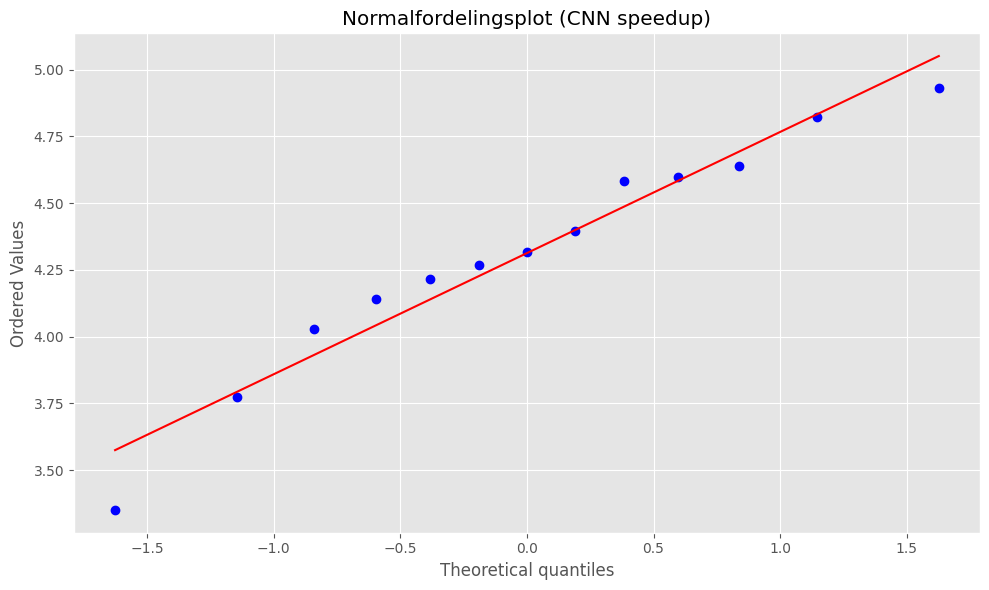

95% CI: (np.float64(4.051682708593119), np.float64(4.5747615990991894))
95% nedre grænse: (np.float64(4.099280647609532), inf)


In [55]:
cnn = np.array([
    3.775302, 3.350679, 4.217981, 4.030324, 4.639692,
    4.139665, 4.395575, 4.824257, 4.268119, 4.584193,
    4.930027, 4.315973, 4.600101,
])
n = len(cnn)
xbar = np.mean(cnn)
s = np.std(cnn, ddof=1)
print(f"n={n}, xbar={xbar:.3f}, s={s:.4f}")

fig, ax = plt.subplots()
probplot(cnn, dist="norm", plot=ax)
ax.set_title("Normalfordelingsplot (CNN speedup)")
plt.tight_layout()
plt.show()

print("95% CI:", ci_mean_sigma_unknown(cnn, 0.95, "two"))
print("95% nedre grænse:", ci_mean_sigma_unknown(cnn, 0.95, "lower"))



**Øvelse 4 - papirvægt ($\chi^2$, ensidet øvre for $\sigma$)**



In [56]:
paper = np.array([
    3.481, 3.448, 3.485, 3.475, 3.472,
    3.477, 3.472, 3.464, 3.472, 3.470,
    3.470, 3.470, 3.477, 3.473, 3.474,
])
n = len(paper)
s = np.std(paper, ddof=1)
nu = n - 1
alpha = 0.05
chi_crit = chi2.ppf(1 - alpha, nu)  # = chi^2_{0.95,14} i facit-noteringen
upper_sigma_sq = nu * s**2 / chi_crit
print(f"s={s:.5f}, øvre 95% grænse for sigma: {np.sqrt(upper_sigma_sq):.4f}")


s=0.00831, øvre 95% grænse for sigma: 0.0064



**Øvelse 5 - Ohio-andel**



In [57]:
x, n = 412, 768
print("95% CI:", ci_proportion_wald(x, n, 0.95, "two"))
print("95% nedre grænse:", ci_proportion_wald(x, n, 0.95, "lower"))


95% CI: (np.float64(0.5011904116290684), np.float64(0.5717262550375983))
95% nedre grænse: (np.float64(0.5068605604212387), 1.0)



---

## 9. Opsummering

| Situation | Fordeling / metode |
|-----------|-------------------|
| $\mu$, $\sigma$ kendt | $z$ |
| $\mu$, $\sigma$ ukendt | $t_{n-1}$ |
| Ny observation | Prædiktion: $\sqrt{1+1/n}$-faktor |
| $\sigma^2$ / $\sigma$ | $\chi^2_{n-1}$ |
| $\mu_1-\mu_2$, ens ukendt varians | Pooled $t_{n_1+n_2-2}$ |
| Andel $p$, stor $n$ | Wald ($z$) |

**Du skal kunne:** vælge rigtig fordeling, skelne CI for $\mu$ fra prædiktionsinterval, og implementere beregningerne i Python.
